In [1]:
# ============================================================
# NOTEBOOK 5 — DEEP LEARNING : AUTOENCODER
# Anomaly Detection on Padel Matches
# Business Objective: Detect unusual/suspicious matches
# to help federations monitor sporting integrity and
# help analysts identify extraordinary performances
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, RocCurveDisplay)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print(f"✅ TensorFlow version: {tf.__version__}")
print("✅ All libraries imported")

✅ TensorFlow version: 2.21.0
✅ All libraries imported


In [2]:
# ============================================================
# 1. DATA LOADING
# ============================================================
matches = pd.read_csv('../data/clean_matches.csv')

print(f"Matches dataset shape: {matches.shape}")
print(f"\nColumns: {list(matches.columns)}")
print(f"\nSample:")
matches.head()

Matches dataset shape: (1260, 16)

Columns: ['id', 'name', 'category', 'round', 'round_name', 'index', 'played_at', 'status', 'score', 'winner', 'duration_minutes', 'players', 'competition_source', 'season_year', 'tournament_name', 'court']

Sample:


,id,name,category,round,round_name,index,played_at,status,score,winner,duration_minutes,players,competition_source,season_year,tournament_name,court
0,6987,Tapia/Coello - Chingotto/Galan,men,1,Finals,0,2025-12-14,finished,"[{'team_1': '6(4)', 'team_2': '7'}, {'team_1':...",team_1,172.0,"{'team_1': [{'id': 66, 'self': '/api/players/6...",FIP,2026,Season 5,Center Court
1,7018,Triay/Brea - Fernandez/Gonzalez,women,1,Finals,0,2025-12-14,finished,"[{'team_1': '4', 'team_2': '6'}, {'team_1': '6...",team_2,129.0,"{'team_1': [{'id': 433, 'self': '/api/players/...",FIP,2026,Season 5,Center Court
2,6985,Tapia/Coello - Di Nenno/Stupaczuk,men,2,Semifinals,0,2025-12-13,finished,"[{'team_1': '7', 'team_2': '5'}, {'team_1': '6...",team_1,104.0,"{'team_1': [{'id': 66, 'self': '/api/players/6...",FIP,2026,Season 5,Center Court
3,6986,Navarro/Sanz - Chingotto/Galan,men,2,Semifinals,1,2025-12-13,finished,"[{'team_1': '2', 'team_2': '6'}, {'team_1': '4...",team_2,95.0,"{'team_1': [{'id': 77, 'self': '/api/players/7...",FIP,2026,Season 5,Center Court
4,7016,Triay/Brea - Ustero/Araujo,women,2,Semifinals,0,2025-12-13,finished,"[{'team_1': '6', 'team_2': '1'}, {'team_1': '6...",team_1,97.0,"{'team_1': [{'id': 433, 'self': '/api/players/...",FIP,2026,Season 5,Center Court


In [3]:
# ============================================================
# 2. EDA
# ============================================================
print("=== Missing Values ===")
print(matches.isnull().sum())
print(f"\n=== Status distribution ===")
print(matches['status'].value_counts())
print(f"\n=== Category distribution ===")
print(matches['category'].value_counts())
print(f"\n=== Round distribution ===")
print(matches['round_name'].value_counts())
print(f"\n=== Duration stats ===")
print(matches['duration_minutes'].describe())

=== Missing Values ===
id                      0
name                   82
category                0
round                   0
round_name              0
index                   0
played_at               0
status                  0
score                 375
winner                116
duration_minutes      624
players                 0
competition_source      0
season_year             0
tournament_name         0
court                 699
dtype: int64

=== Status distribution ===
status
finished    874
bye         363
walkover     12
retired      11
Name: count, dtype: int64

=== Category distribution ===
category
men      692
women    568
Name: count, dtype: int64

=== Round distribution ===
round_name
Round of 32    480
Round of 64    316
Round of 16    240
Quarter        128
Semifinals      64
Finals          32
Name: count, dtype: int64

=== Duration stats ===
count    636.000000
mean      89.775157
std       32.339120
min        5.000000
25%       67.000000
50%       83.000000
75%    

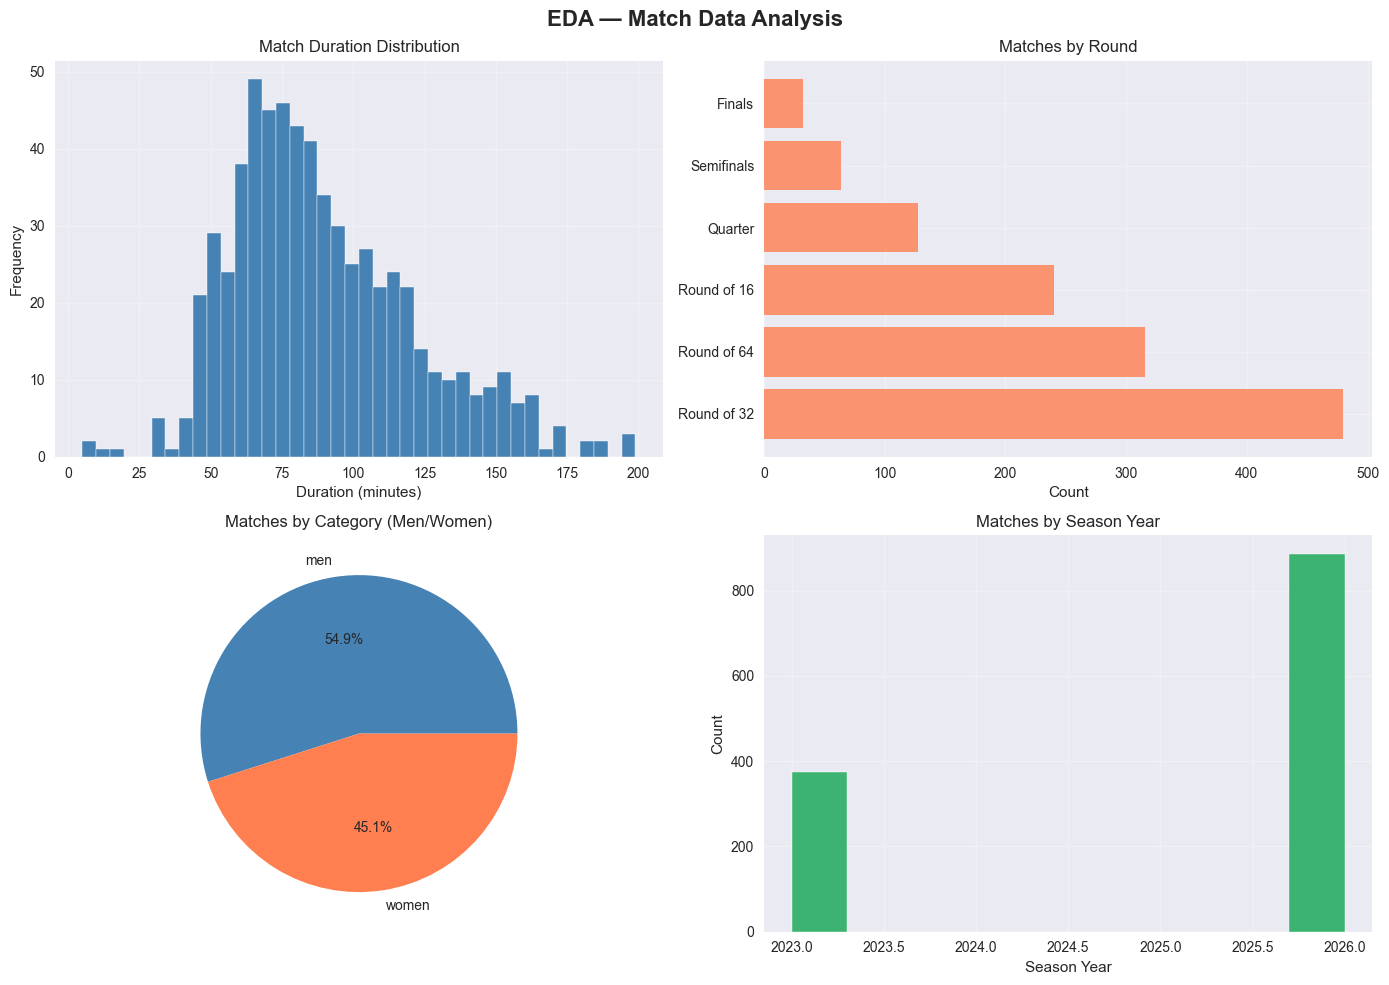

✅ EDA saved


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Match Data Analysis', fontsize=16, fontweight='bold')

# Duration distribution
matches['duration_minutes'].dropna().hist(
    bins=40, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Match Duration Distribution')
axes[0,0].set_xlabel('Duration (minutes)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].grid(True, alpha=0.3)

# Round distribution
round_counts = matches['round_name'].value_counts()
axes[0,1].barh(round_counts.index, round_counts.values, color='coral', alpha=0.8)
axes[0,1].set_title('Matches by Round')
axes[0,1].set_xlabel('Count')
axes[0,1].grid(True, alpha=0.3)

# Category distribution
cat_counts = matches['category'].value_counts()
axes[1,0].pie(cat_counts.values, labels=cat_counts.index,
              autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1,0].set_title('Matches by Category (Men/Women)')

# Season year distribution
matches['season_year'].hist(bins=10, ax=axes[1,1], 
                             color='mediumseagreen', edgecolor='white')
axes[1,1].set_title('Matches by Season Year')
axes[1,1].set_xlabel('Season Year')
axes[1,1].set_ylabel('Count')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/eda_autoencoder.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA saved")

In [5]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================
df = matches.copy()

# 1. duration_minutes — fill missing with median
df['duration_minutes'] = df['duration_minutes'].fillna(
    df['duration_minutes'].median())

# 2. Encode category (men/women)
df['category_encoded'] = LabelEncoder().fit_transform(df['category'])

# 3. Encode round
round_order = {
    'Finals': 1, 'Semifinals': 2, 'Quarterfinals': 3,
    'Round of 16': 4, 'Round of 32': 5, 'Round of 64': 6
}
df['round_encoded'] = df['round_name'].map(round_order).fillna(5)

# 4. Encode winner
df['winner_encoded'] = df['winner'].map(
    {'team_1': 0, 'team_2': 1}).fillna(0.5)

# 5. index (match position in tournament)
df['index'] = df['index'].fillna(df['index'].median())

# 6. season_year
df['season_year'] = df['season_year'].fillna(2024)

# 7. duration_per_round (normalized effort)
df['duration_per_round'] = df['duration_minutes'] / df['round_encoded']

# 8. is_final_stage
df['is_final_stage'] = (df['round_encoded'] <= 2).astype(int)

# 9. duration_zscore (how unusual is the duration)
mean_dur = df['duration_minutes'].mean()
std_dur  = df['duration_minutes'].std()
df['duration_zscore'] = (df['duration_minutes'] - mean_dur) / std_dur

feature_cols = [
    'duration_minutes',
    'duration_zscore',
    'duration_per_round',
    'round_encoded',
    'category_encoded',
    'winner_encoded',
    'index',
    'season_year',
    'is_final_stage'
]

X = df[feature_cols].fillna(0)

print(f"✅ Features: {feature_cols}")
print(f"X shape: {X.shape}")
print(f"\nFeature stats:")
print(X.describe().round(2))

✅ Features: ['duration_minutes', 'duration_zscore', 'duration_per_round', 'round_encoded', 'category_encoded', 'winner_encoded', 'index', 'season_year', 'is_final_stage']
X shape: (1260, 9)

Feature stats:
       duration_minutes  duration_zscore  duration_per_round  round_encoded  \
count           1260.00          1260.00             1260.00        1260.00   
mean              86.42            -0.00               20.80           4.81   
std               23.22             1.00               16.16           1.13   
min                5.00            -3.51                1.00           1.00   
25%               83.00            -0.15               13.83           4.00   
50%               83.00            -0.15               16.60           5.00   
75%               84.00            -0.10               20.75           6.00   
max              199.00             4.85              199.00           6.00   

       category_encoded  winner_encoded    index  season_year  is_final_stage  
co

In [6]:
# ============================================================
# 4. SCALING
# Autoencoder trains on NORMAL data only
# Anomalies are detected by high reconstruction error
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train on ALL data — autoencoder learns normal patterns
# Then reconstruction error identifies anomalies
X_train, X_test = train_test_split(
    X_scaled, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} matches")
print(f"Test set:     {X_test.shape[0]} matches")
print(f"\n✅ Autoencoder trains on normal data → learns to reconstruct it")
print(f"✅ Anomalies = matches it CANNOT reconstruct well")

Training set: 1008 matches
Test set:     252 matches

✅ Autoencoder trains on normal data → learns to reconstruct it
✅ Anomalies = matches it CANNOT reconstruct well


In [7]:
# ============================================================
# 5. MODEL EXPLANATION
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║         DEEP LEARNING — AUTOENCODER                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║ INTUITION:                                                  ║
║   An Autoencoder is a neural network that learns to        ║
║   compress data into a smaller representation and then     ║
║   reconstruct it back to the original.                     ║
║                                                             ║
║   ENCODER: Input (9) → 6 → 4 → 2 (bottleneck)            ║
║   DECODER: 2 → 4 → 6 → Output (9)                        ║
║                                                             ║
║   Normal matches → low reconstruction error ✅             ║
║   Anomalous matches → HIGH reconstruction error ❌         ║
║                                                             ║
║ ARCHITECTURE:                                               ║
║   Encoder:                                                  ║
║     Dense(9) → Dense(6, ReLU) → Dense(4, ReLU)            ║
║     → Dense(2, ReLU) ← BOTTLENECK                         ║
║   Decoder:                                                  ║
║     Dense(2) → Dense(4, ReLU) → Dense(6, ReLU)            ║
║     → Dense(9, linear) ← RECONSTRUCTION                   ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - bottleneck size: compression level (2 = aggressive)    ║
║   - threshold: reconstruction error cutoff for anomaly     ║
║   - epochs: training iterations                            ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Normal data is the majority (most matches are normal)  ║
║   - Anomalies have patterns different from normal data     ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Threshold must be set manually                         ║
║   - No labels — unsupervised approach                     ║
║   - May flag rare but legitimate events as anomalies       ║
║                                                             ║
║ WHY BETTER THAN ISOLATION FOREST HERE:                     ║
║   - Learns complex non-linear patterns                     ║
║   - Reconstruction error is more interpretable             ║
║   - Can be extended to detect specific anomaly types       ║
║   - Industry standard for deep anomaly detection           ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         DEEP LEARNING — AUTOENCODER                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║ INTUITION:                                                  ║
║   An Autoencoder is a neural network that learns to        ║
║   compress data into a smaller representation and then     ║
║   reconstruct it back to the original.                     ║
║                                                             ║
║   ENCODER: Input (9) → 6 → 4 → 2 (bottleneck)            ║
║   DECODER: 2 → 4 → 6 → Output (9)                        ║
║                                                             ║
║   Normal matches → low reconstruction error ✅             ║
║   Anomalous matches → HIGH reconstruction error ❌         ║
║                                                             ║
║ ARCHITECTURE:                                   

In [8]:
# ============================================================
# 6. BUILD AUTOENCODER
# ============================================================
input_dim = X_train.shape[1]

def build_autoencoder(input_dim, bottleneck=2):
    # ENCODER
    inputs = keras.Input(shape=(input_dim,))
    encoded = layers.Dense(6, activation='relu')(inputs)
    encoded = layers.Dense(4, activation='relu')(encoded)
    bottleneck_layer = layers.Dense(bottleneck, activation='relu',
                                     name='bottleneck')(encoded)
    
    # DECODER
    decoded = layers.Dense(4, activation='relu')(bottleneck_layer)
    decoded = layers.Dense(6, activation='relu')(decoded)
    outputs = layers.Dense(input_dim, activation='linear')(decoded)
    
    autoencoder = keras.Model(inputs, outputs, name='autoencoder')
    
    # Encoder only model (for visualization)
    encoder = keras.Model(inputs, bottleneck_layer, name='encoder')
    
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(input_dim, bottleneck=2)
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 9)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 6)                   │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │              28 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bottleneck (Dense)                   │ (None, 2)                   │              10 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 9)                   │              63 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 203 (812.00 B)

 Trainable params: 203 (812.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ============================================================
# 7. TRAINING
# ============================================================
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1)
]

print("🔥 Training Autoencoder...")
history = autoencoder.fit(
    X_train, X_train,  # Input = Output (reconstruction)
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("✅ Autoencoder training complete!")

🔥 Training Autoencoder...
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.0285 - val_loss: 0.9549
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0238 - val_loss: 0.9488
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0174 - val_loss: 0.9397
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0078 - val_loss: 0.9265
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9949 - val_loss: 0.9118
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9813 - val_loss: 0.8980
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9687 - val_loss: 0.8857
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9574 - val_loss: 0.8730
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9458 - val_loss: 0.8602
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9324 - val_loss: 0.8444
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9148 - val_loss: 0.8231
Epoch 12/100
26/26 ━━━━━━━━━━━━━━━━━

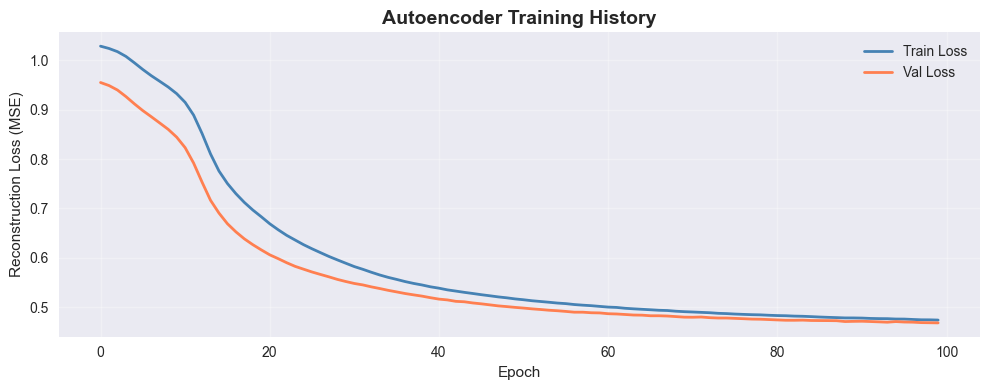

✅ Training history saved


In [10]:
# ============================================================
# 8. TRAINING HISTORY
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
ax.plot(history.history['val_loss'], label='Val Loss', color='coral', linewidth=2)
ax.set_title('Autoencoder Training History', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction Loss (MSE)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/autoencoder_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history saved")

In [11]:
# ============================================================
# 9. ANOMALY DETECTION
# ============================================================

# Reconstruction error on ALL data
X_reconstructed = autoencoder.predict(X_scaled, verbose=0)
reconstruction_errors = np.mean(np.power(X_scaled - X_reconstructed, 2), axis=1)

df['reconstruction_error'] = reconstruction_errors

# Set threshold — 95th percentile = top 5% are anomalies
threshold = np.percentile(reconstruction_errors, 95)
df['is_anomaly'] = (reconstruction_errors > threshold).astype(int)

print(f"Reconstruction Error Statistics:")
print(f"  Mean:      {reconstruction_errors.mean():.4f}")
print(f"  Std:       {reconstruction_errors.std():.4f}")
print(f"  Min:       {reconstruction_errors.min():.4f}")
print(f"  Max:       {reconstruction_errors.max():.4f}")
print(f"  Threshold (95th percentile): {threshold:.4f}")
print(f"\n✅ Anomalies detected: {df['is_anomaly'].sum()} matches")
print(f"   ({df['is_anomaly'].mean()*100:.1f}% of all matches)")

print(f"\n📋 Sample Anomalous Matches:")
anomalies = df[df['is_anomaly'] == 1][
    ['round_name', 'category', 'duration_minutes', 
     'season_year', 'reconstruction_error']
].sort_values('reconstruction_error', ascending=False)
print(anomalies.head(10).to_string())

Reconstruction Error Statistics:
  Mean:      0.4674
  Std:       0.2340
  Min:       0.1324
  Max:       3.4563
  Threshold (95th percentile): 0.8675

✅ Anomalies detected: 63 matches
   (5.0% of all matches)

📋 Sample Anomalous Matches:
       round_name category  duration_minutes  season_year  reconstruction_error
882        Finals    women             199.0         2026              3.456350
0          Finals      men             172.0         2026              2.671365
1171       Finals    women             154.0         2023              2.011614
788        Finals    women             159.0         2026              1.907056
1170       Finals      men             124.0         2023              1.583587
55    Round of 32      men               7.0         2026              1.531300
599   Round of 32      men               5.0         2026              1.450507
443        Finals      men             120.0         2026              1.292602
567   Round of 64      men              4

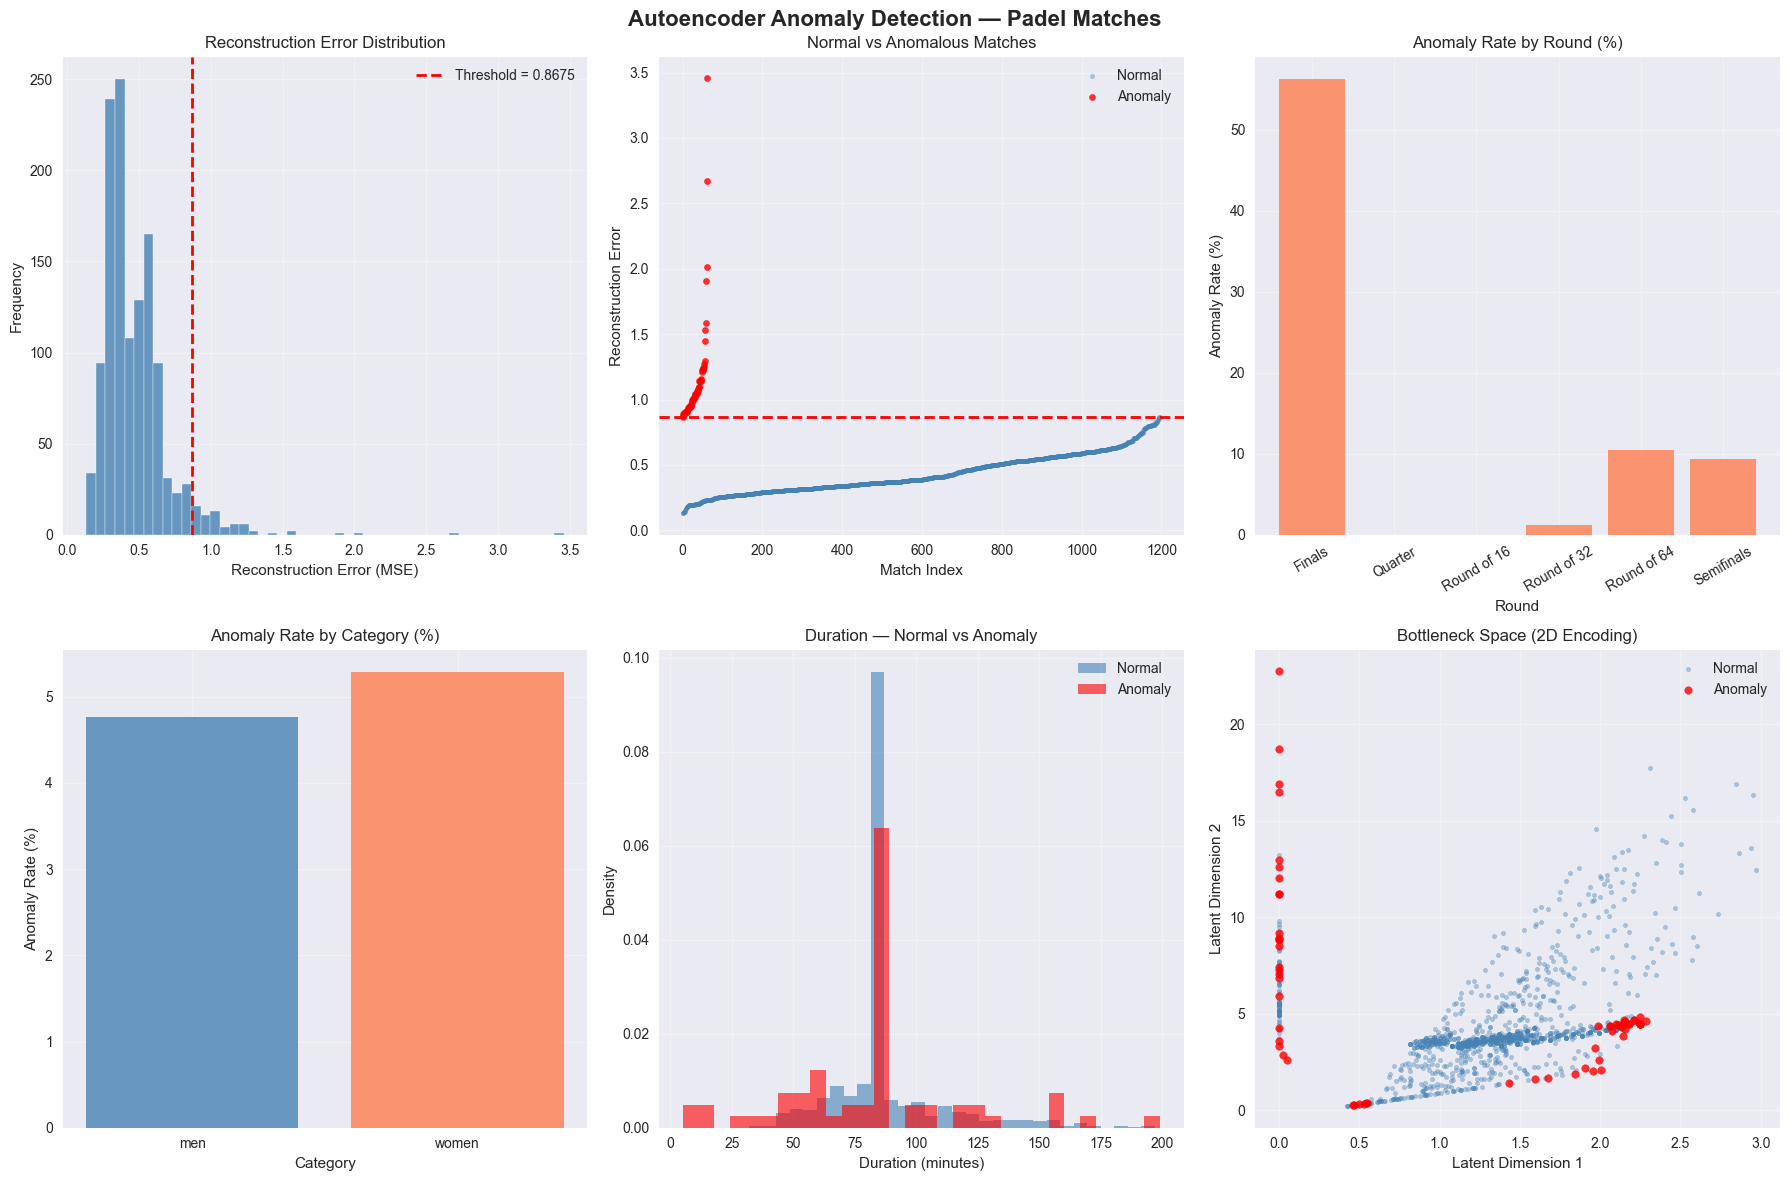

✅ All visualizations saved


In [12]:
# ============================================================
# 10. VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Autoencoder Anomaly Detection — Padel Matches',
             fontsize=16, fontweight='bold')

# Reconstruction error distribution
axes[0,0].hist(reconstruction_errors, bins=50, 
               color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(x=threshold, color='red', linestyle='--', 
                   linewidth=2, label=f'Threshold = {threshold:.4f}')
axes[0,0].set_title('Reconstruction Error Distribution')
axes[0,0].set_xlabel('Reconstruction Error (MSE)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Normal vs Anomaly scatter
normal_errors   = reconstruction_errors[df['is_anomaly'] == 0]
anomaly_errors  = reconstruction_errors[df['is_anomaly'] == 1]
axes[0,1].scatter(range(len(normal_errors)), 
                   sorted(normal_errors), 
                   alpha=0.4, s=10, color='steelblue', label='Normal')
axes[0,1].scatter(range(len(anomaly_errors)), 
                   sorted(anomaly_errors),
                   alpha=0.8, s=20, color='red', label='Anomaly')
axes[0,1].axhline(y=threshold, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title('Normal vs Anomalous Matches')
axes[0,1].set_xlabel('Match Index')
axes[0,1].set_ylabel('Reconstruction Error')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Anomalies by Round
anomaly_by_round = df.groupby('round_name')['is_anomaly'].mean() * 100
axes[0,2].bar(anomaly_by_round.index, anomaly_by_round.values,
              color='coral', alpha=0.8)
axes[0,2].set_title('Anomaly Rate by Round (%)')
axes[0,2].set_xlabel('Round')
axes[0,2].set_ylabel('Anomaly Rate (%)')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].grid(True, alpha=0.3)

# Anomalies by Category
anomaly_by_cat = df.groupby('category')['is_anomaly'].mean() * 100
axes[1,0].bar(anomaly_by_cat.index, anomaly_by_cat.values,
              color=['steelblue', 'coral'], alpha=0.8)
axes[1,0].set_title('Anomaly Rate by Category (%)')
axes[1,0].set_xlabel('Category')
axes[1,0].set_ylabel('Anomaly Rate (%)')
axes[1,0].grid(True, alpha=0.3)

# Duration of anomalous vs normal matches
axes[1,1].hist(df[df['is_anomaly']==0]['duration_minutes'].dropna(),
               bins=30, alpha=0.6, color='steelblue', label='Normal', density=True)
axes[1,1].hist(df[df['is_anomaly']==1]['duration_minutes'].dropna(),
               bins=30, alpha=0.6, color='red', label='Anomaly', density=True)
axes[1,1].set_title('Duration — Normal vs Anomaly')
axes[1,1].set_xlabel('Duration (minutes)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Encoder 2D visualization (bottleneck)
X_encoded = encoder.predict(X_scaled, verbose=0)
axes[1,2].scatter(X_encoded[df['is_anomaly']==0, 0],
                   X_encoded[df['is_anomaly']==0, 1],
                   alpha=0.4, s=10, color='steelblue', label='Normal')
axes[1,2].scatter(X_encoded[df['is_anomaly']==1, 0],
                   X_encoded[df['is_anomaly']==1, 1],
                   alpha=0.8, s=30, color='red', label='Anomaly')
axes[1,2].set_title('Bottleneck Space (2D Encoding)')
axes[1,2].set_xlabel('Latent Dimension 1')
axes[1,2].set_ylabel('Latent Dimension 2')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/autoencoder_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All visualizations saved")

In [13]:
# ============================================================
# 11. ANOMALY PROFILING
# What makes a match anomalous?
# ============================================================
print("=== ANOMALY PROFILE vs NORMAL MATCHES ===\n")

profile = df.groupby('is_anomaly')[
    ['duration_minutes', 'round_encoded', 
     'reconstruction_error', 'duration_zscore']
].mean().round(3)

profile.index = ['Normal ✅', 'Anomaly ❌']
print(profile.to_string())

print("\n=== ANOMALOUS MATCHES BREAKDOWN ===")
print(f"\nBy Round:")
print(df[df['is_anomaly']==1]['round_name'].value_counts())
print(f"\nBy Category:")
print(df[df['is_anomaly']==1]['category'].value_counts())
print(f"\nBy Season Year:")
print(df[df['is_anomaly']==1]['season_year'].value_counts())
print(f"\nDuration Statistics — Anomalous Matches:")
print(df[df['is_anomaly']==1]['duration_minutes'].describe().round(2))

=== ANOMALY PROFILE vs NORMAL MATCHES ===

           duration_minutes  round_encoded  reconstruction_error  duration_zscore
Normal ✅             86.678          4.844                 0.432            0.011
Anomaly ❌            81.508          4.095                 1.146           -0.212

=== ANOMALOUS MATCHES BREAKDOWN ===

By Round:
round_name
Round of 64    33
Finals         18
Semifinals      6
Round of 32     6
Name: count, dtype: int64

By Category:
category
men      33
women    30
Name: count, dtype: int64

By Season Year:
season_year
2026    36
2023    27
Name: count, dtype: int64

Duration Statistics — Anomalous Matches:
count     63.00
mean      81.51
std       37.24
min        5.00
25%       59.50
50%       83.00
75%       83.00
max      199.00
Name: duration_minutes, dtype: float64


In [14]:
# ============================================================
# 12. AUTOENCODER vs CLASSICAL ANOMALY DETECTION
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(X_scaled)
iso_anomalies = (iso_labels == -1).astype(int)

# LOF
lof = LocalOutlierFactor(contamination=0.05)
lof_labels = lof.fit_predict(X_scaled)
lof_anomalies = (lof_labels == -1).astype(int)

print("=== COMPARISON — Anomalies Detected ===\n")
comparison = pd.DataFrame({
    'Method': ['Autoencoder (Deep Learning)', 
               'Isolation Forest (Classical)',
               'LOF (Classical)'],
    'Anomalies Detected': [df['is_anomaly'].sum(),
                            iso_anomalies.sum(),
                            lof_anomalies.sum()],
    'Anomaly Rate (%)': [df['is_anomaly'].mean()*100,
                          iso_anomalies.mean()*100,
                          lof_anomalies.mean()*100],
    'Type': ['Deep Learning', 'Classical ML', 'Classical ML']
}).set_index('Method')

print(comparison.round(2).to_string())

# Agreement analysis
agreement_iso = (df['is_anomaly'] == iso_anomalies).mean() * 100
agreement_lof = (df['is_anomaly'] == lof_anomalies).mean() * 100
print(f"\nAgreement Autoencoder vs Isolation Forest: {agreement_iso:.1f}%")
print(f"Agreement Autoencoder vs LOF: {agreement_lof:.1f}%")
print(f"\nMatches flagged by ALL 3 methods: {((df['is_anomaly']==1) & (iso_anomalies==1) & (lof_anomalies==1)).sum()}")
print(f"→ These are the MOST SUSPICIOUS matches")

=== COMPARISON — Anomalies Detected ===

                              Anomalies Detected  Anomaly Rate (%)           Type
Method                                                                           
Autoencoder (Deep Learning)                   63               5.0  Deep Learning
Isolation Forest (Classical)                  63               5.0   Classical ML
LOF (Classical)                               63               5.0   Classical ML

Agreement Autoencoder vs Isolation Forest: 94.0%
Agreement Autoencoder vs LOF: 92.4%

Matches flagged by ALL 3 methods: 6
→ These are the MOST SUSPICIOUS matches


In [15]:
# ============================================================
# 13. BUSINESS INSIGHTS
# ============================================================
most_suspicious = df[
    (df['is_anomaly']==1) & 
    (iso_anomalies==1) & 
    (lof_anomalies==1)
][['round_name', 'category', 'duration_minutes', 
   'season_year', 'reconstruction_error']].sort_values(
    'reconstruction_error', ascending=False)

print(f"🚨 Most Suspicious Matches (flagged by ALL 3 methods):")
print(most_suspicious.head(10).to_string())

print("""
╔══════════════════════════════════════════════════════════════╗
║                    BUSINESS INSIGHTS                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  🎯 OBJECTIVE: Detect unusual matches automatically         ║
║                                                             ║
║  📊 AUTOENCODER ADVANTAGE over Classical Methods:          ║
║  → Learns complex non-linear patterns in match data        ║
║  → Reconstruction error is more interpretable              ║
║  → Bottleneck space reveals match clustering               ║
║  → Scalable to new match data without retraining labels    ║
║                                                             ║
║  🔍 WHAT MAKES A MATCH ANOMALOUS?                          ║
║  → Unusually long or short duration                        ║
║  → Unexpected round for match intensity                    ║
║  → Atypical winner pattern for the round stage             ║
║                                                             ║
║  💼 RECOMMENDATIONS:                                        ║
║                                                             ║
║  FOR FEDERATIONS (Integrity):                               ║
║  → Automatically flag matches for review                   ║
║  → Prioritize investigation of matches flagged             ║
║     by ALL 3 detection methods simultaneously              ║
║  → Build historical anomaly database for patterns          ║
║                                                             ║
║  FOR ANALYSTS:                                              ║
║  → Anomalous matches = extraordinary performances          ║
║  → Use for upset analysis and bracket predictions          ║
║  → Identify which rounds produce most surprises            ║
║                                                             ║
║  FOR ORGANIZERS & MEDIA:                                    ║
║  → Anomalous matches = most exciting content               ║
║  → Prioritize these for highlight reels                    ║
║  → Use predictions to promote potentially exciting         ║
║     upcoming matches before they happen                    ║
║                                                             ║
╚══════════════════════════════════════════════════════════════╝
""")

autoencoder.save('../models/autoencoder_matches.keras')
print("✅ Autoencoder saved to ../models/")

🚨 Most Suspicious Matches (flagged by ALL 3 methods):
       round_name category  duration_minutes  season_year  reconstruction_error
882        Finals    women             199.0         2026              3.456350
0          Finals      men             172.0         2026              2.671365
1171       Finals    women             154.0         2023              2.011614
788        Finals    women             159.0         2026              1.907056
567   Round of 64      men              40.0         2026              1.267805
550   Round of 64    women              47.0         2026              1.210229

╔══════════════════════════════════════════════════════════════╗
║                    BUSINESS INSIGHTS                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  🎯 OBJECTIVE: Detect unusual matches automatically         ║
║                                                             ║

In [16]:
# Save results for Streamlit
output_cols = ['round_name', 'category', 'duration_minutes', 'season_year',
               'reconstruction_error', 'is_anomaly', 'duration_zscore', 'round_encoded']
df[output_cols].to_csv('../data/autoencoder_results_matches.csv', index=False)

# Save comparison stats
comparison_stats = {
    'autoencoder_anomalies': int(df['is_anomaly'].sum()),
    'iso_anomalies': int(iso_anomalies.sum()),
    'lof_anomalies': int(lof_anomalies.sum()),
    'agreement_iso': float(agreement_iso),
    'agreement_lof': float(agreement_lof),
    'all_three': int(((df['is_anomaly']==1) & (iso_anomalies==1) & (lof_anomalies==1)).sum()),
    'threshold': float(df['reconstruction_error'].quantile(0.95)),
    'total_matches': int(len(df))
}
import json
with open('../data/autoencoder_stats.json', 'w') as f:
    json.dump(comparison_stats, f)
print("✅ Results saved for Streamlit!")

✅ Results saved for Streamlit!
